# Edit 共用原图池：4B 三级分类剪枝

入口：下方唯一配置格声明实验参数，`source_image_pipeline.run_pipeline(cfg)` 执行。读全库概念按 taxonomy 前三层归类，第一层作为大域；4B 只看大域和分类路径，不提供概念名称、别名或代表样例。

输入：`datasets/master_concepts.lance@2`（385,292 个概念）与公共 `datasets/images.lance@9`（2,164,671 张图）。默认 taxonomy_depth=3，实测归为 7,917 个分类、29 个大域。例如“动物 / 鸟类 / 猛禽 / 鹰”归入“动物 / 鸟类 / 猛禽”；不足三层保留已有路径，无分类单独留组。同一概念的多条深层路径落在同类时先去重。

数据流：读主表 → 按前 N 层归类、计数 → 写 category_inputs；4B 每分类一次宽松 keep/hold/reject → 写 category_results；keep 分类展开全部成员概念、多路径合并 → 写 concept_candidates；关联公共图片、SHA 去重 → 复用尺寸并要求短边 >1024 → 写 image_checks；每概念和全局限量 → 写 image_inputs；27B 每图一次标注 → 写 image_results；keep 图片 → 写 unreviewed 原图池。

分类粗筛只决定召回范围：存在稳定可用的一批场景、空间或承载面来源即可 keep，不因类别混杂整体排除；明确无关才 reject；hold 留在分类结果中供复查，本轮不进入视觉阶段。具体错绑、图像质量及可编辑区域由视觉模型看像素判断。概念数用于检查范围，不发给文本模型，也不逐概念调用 4B。

默认全分类判断，文本预算 8,000 次覆盖 7,917 类；首轮每概念最多 4 张、全局最多 500 张进入视觉标注。先查看下方视觉 keep 比例和阶段耗时，再将配置格的 image_limit 改为 5000 扩池；保留同一 run 和 overwrite，已完成的相同请求会复用，目标表更新为扩池后的完整结果。最终入池数由筛选决定，500/5000 都是视觉输入上限。先看分类可将 through 改为 categories，再改回 pool 继续；相同分类请求复用日志，类别不变时增加成员概念也不重复调用。offline 只登记/复用请求，local 按配置加载文本 8002、视觉 8000 服务；两阶段先后执行，每阶段两卡各一份模型，阶段结束释放显存。

输出在本模块 datasets，运行名 scene_pool_category_l3_v1；公共来源只读。新协议用新表名，历史运行及 notebook 已保存输出不回写。可在 notebook 手工运行；本轮按用户授权由后台直接执行同一份 notebook。

后台执行：直接用 nbconvert 执行本 notebook，内核为 demiwtg（项目 env）。当前参数为完整 7,917 类 + 首轮 500 张图片；文本/视觉总并发 128/32，每个阶段均使用 GPU0+GPU1（DP=2、TP=1）。进度写入 datasets/run__scene_pool_category_l3_v1_background_dual_gpu_resume.log，执行副本保存到 reviews/source_image_background_dual_gpu_resume_20260927.ipynb。源 notebook 的历史输出保持，后台实际输出看执行副本。


In [1]:
import sys
from pathlib import Path
PROJECT = Path("/yzp/zhaozy/yangzepeng/0905/demiwtg")
sys.path.insert(0, str(PROJECT)) if str(PROJECT) not in sys.path else None
import io
import json
import lance
from PIL import Image
from IPython.display import display
from project import resolve_root
from demiflow.lance.blobs import BlobRef

root = resolve_root()


In [2]:
# 配置入口：重读磁盘上的入口模块，避免内核缓存旧 config 的参数签名。
# 本格只加载代码并声明参数；下一格 run_pipeline 才读业务数据、调用模型和写表。
import importlib
from benchmark.edit.source_images.operaters import model_service as source_model_service
importlib.reload(source_model_service)
from benchmark.edit.source_images.operaters import sources as source_image_ops
importlib.reload(source_image_ops)
from benchmark.edit.source_images import source_image_pipeline
source_image_pipeline = importlib.reload(source_image_pipeline)

# 图片试跑/扩池共用一个限额：首轮 500，检查结果后改成 5000；两个图片参数一起更新。
image_limit = 500
# 模型加载配置：run_pipeline 在每个模型阶段加载，阶段结束释放显存。
# 每卡一份同模型（DP=2、TP=1）；vLLM 在单一 API 端口内分配请求。
# 外部服务模式把 text_service/vision_service 设为 None；已占用端口不会自动接管。
service_common = dict(
    python=sys.executable, cuda_bin='/usr/local/cuda/bin',
    gpus=[0, 1], data_parallel_size=2, tensor_parallel_size=1,
    api_server_count=1, enforce_eager=False,
    startup_timeout_s=900, shutdown_timeout_s=30,
    poll_interval_s=1, startup_log_interval_s=15,
)
cfg = source_image_pipeline.config(
    # 输出：新分类协议用独立运行名；最终池默认 pool__scene_pool_category_l3_v1.lance。
    run=root / source_image_pipeline.DATASETS / 'scene_pool_category_l3_v1',
    target_uri=None, write_mode='overwrite',
    # 输入：公共主表与全量图片目录固定版本；Blob 沿 source_refs 自带位置/版本读取。
    concept_source={'uri': 'datasets/master_concepts.lance', 'version': 2},
    image_source={'uri': 'datasets/images.lance', 'version': 9},

    # 分类范围：先按 taxonomy 前三层归类，首层记为大域；4B 只看分类信息。
    taxonomy_depth=3,  # 例：动物 / 鸟类 / 猛禽 / 鹰 → 动物 / 鸟类 / 猛禽。
    # [] 不预设场景/家具白名单，覆盖全库所有三级分类。
    taxonomy_prefixes=[],
    concepts=None, max_concepts=None,  # 不截取前 200 个；精确 concepts 仅用于隔离调试。
    # 文本输入只有 domain/category；成员数留表核对，不传概念/别名/样例给模型。
    # keep 后展开该分类全部成员，不再逐概念调用 4B。

    # 图片策略：demiflow flat_map 展开 concept×SHA，再 join 候选概念；不把名单拼成 SQL。
    # 召回包含无历史标注行，已知尺寸复用，缺失才沿固定 Blob 补读。
    published_only=False,
    min_short_side=1024,  # 严格 >；小图先排除，不占后面的标注名额。
    # 池规模与文本剪枝独立：每概念最多 4 张，SHA 去重后按 image_limit 限量。
    # 这是视觉输入上限，不承诺最终 keep 数量；可按实际覆盖/预算调整。
    max_images_per_concept=4, max_images=image_limit,

    # 执行边界：categories（只做分类）/ image_inputs（含关联过滤）/ pool（视觉标注与交付）。
    # local 按下方 service 配置加载模型；offline 只登记/复用响应，不加载模型。
    mode='local', through='pool',
    text_model={'name': 'qwen3-4b-instruct-2507', 'base_url': 'http://127.0.0.1:8002/v1'},
    vision_model={'name': 'qwen3.8-27b', 'base_url': 'http://127.0.0.1:8000/v1'},
    # 权重从本地加载；4B 分类完成后释放两卡，再加载两份 27B 做图片标注。
    # 模型加载参数控制服务，下面 max_tokens/预处理参数控制每条请求。
    text_service={**service_common, 'model_path': str(root / 'models/Qwen3-4B-Instruct-2507'),
                  'gpu_memory_utilization': 0.35, 'max_model_len': 8192,
                  'max_num_seqs': 64, 'max_num_batched_tokens': 16384},
    vision_service={**service_common, 'model_path': str(root / 'models/Qwen3.8-27B'),
                    'gpu_memory_utilization': 0.90, 'max_model_len': 65536,
                    'max_num_seqs': 16, 'max_num_batched_tokens': 16384},
    # 换 Gemma 时同步 vision_model、vision_service 权重路径和下面图片预处理参数。
    # 文本预算按分类计：8,000 覆盖当前 7,917 类；图片预算与 image_limit 一起控制。
    max_text_calls=8000, max_image_calls=image_limit,
    # 后台直接执行本 notebook：4B 每卡最多 64 个请求，27B 每卡最多 16 个。
    # 调用日志已合并小分片并复用表句柄，减少 CPU 扫描；并发用于持续填充服务队列。
    # queue_depth 是输入缓冲条数，不是请求并发；图片载荷较大，保持 2 控制预取内存。
    text_concurrency=128, vision_concurrency=32, queue_depth=2,
    # 输入文本：模板+载荷最多 16000 字符；超限写 needs_context_budget，不截断。
    # 这是字符预算，不是 token 计数；服务仍校验最终图文输入+输出能否放入上下文。
    max_context_chars=16000,
    # 输出：为 JSON 留余量；是生成上限，遇到结束符会提前停止，不强制生成这么长。
    # 当前服务上下文为 4B=8192、27B=65536；修改输出值不会扩大服务端上下文。
    text_max_tokens=1024, vision_max_tokens=4096,
    text_enable_thinking=False, vision_enable_thinking=False,
    # Qwen 图片输入：按 patch 16 × merge 2，将处理像素限制为最多约 2048 个视觉 token。
    # size 中这两个字段在此处理器里表示像素总面积，不是边长；缩放与网格对齐由服务完成。
    # 只限制标注时的看图精度；池内仍指向完整原图，短边 >1024 的入选要求不变。
    # 改 Gemma 等模型时传 None 或该模型支持的参数，不沿用 Qwen 的像素/token 换算。
    vision_mm_processor_kwargs={'size': {'shortest_edge': 65536, 'longest_edge': 2048 * 32 * 32}},
    timeout_s=300, temperature=0,
    max_keepalive_connections=0,  # 本地请求使用新连接，避免空闲连接失效影响长批次。
    log_path=root / source_image_pipeline.DATASETS / 'run__scene_pool_category_l3_v1_background_dual_gpu_resume.log',
    # 进度：每完成 50 条或距上次输出 15 秒，在下一条结果上打印；首条/末条/首种错误也打印。
    # 显示本次处理数、响应复用、技术状态和 keep/hold/reject；没有新结果时不产生定时心跳。
    # 只改日志频率不会改变请求身份；同一 run 的完整响应仍可复用。
    log_every=50, log_interval_s=15,
)


In [3]:
# 执行入口：按 cfg 读取来源 → 处理/调用模型 → 写阶段表，返回截至 through 的摘要。
# complete 判断行处理是否完成，不表示所有行都 keep；pending/失败使其为 False。
import asyncio

result = await asyncio.to_thread(source_image_pipeline.run_pipeline, cfg)
result


[Edit 原图][scene_pool_category_l3_v1][+0.0s] 输入：/yzp/zhaozy/yangzepeng/0905/datasets/master_concepts.lance@2；/yzp/zhaozy/yangzepeng/0905/datasets/images.lance@9；目标池=/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/edit/source_images/datasets/pool__scene_pool_category_l3_v1.lance
[Edit 原图][scene_pool_category_l3_v1][+0.0s] 按 taxonomy 前 3 层分组；4B 只看大域和分类路径
[Edit 原图][scene_pool_category_l3_v1][+19.2s] 范围：385292 个概念、7917 个分类分组
[Edit 原图][scene_pool_category_l3_v1][+19.2s] 分类开始：模型=qwen3-4b-instruct-2507，并发=128，新请求预算=8000；相同完整响应从 demiwtg/benchmark/edit/source_images/datasets/calls__scene_pool_category_l3_v1.lance 复用
[Edit 原图][scene_pool_category_l3_v1][+19.3s] 加载模型 qwen3-4b-instruct-2507：GPU=[0, 1]，DP=2，TP=1；服务日志=/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/edit/source_images/datasets/model__scene_pool_category_l3_v1__text.log
[Edit 原图][scene_pool_category_l3_v1][+34.4s] 模型仍在加载：qwen3-4b-instruct-2507，已等 15s；日志=/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/edit/source_images/datasets/model__scene_

[2026-09-27T14:32:22Z WARN  lance::dataset::write::insert] No existing dataset at /yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/edit/source_images/datasets/image_checks__scene_pool_category_l3_v1.lance, it will be created


[Edit 原图][scene_pool_category_l3_v1][+2225.6s] 图片关联与尺寸检查已写入 /yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/edit/source_images/datasets/image_checks__scene_pool_category_l3_v1.lance@1，共 1067320 张
[Edit 原图][scene_pool_category_l3_v1][+2250.3s] 视觉输入已写入 /yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/edit/source_images/datasets/image_inputs__scene_pool_category_l3_v1.lance@1，共 500 张
[Edit 原图][scene_pool_category_l3_v1][+2250.3s] 视觉标注：500 张，模型=qwen3.8-27b，并发=32，新请求预算=500
[Edit 原图][scene_pool_category_l3_v1][+2250.4s] 加载模型 qwen3.8-27b：GPU=[0, 1]，DP=2，TP=1；服务日志=/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/edit/source_images/datasets/model__scene_pool_category_l3_v1__vision.log


[2026-09-27T14:37:57Z WARN  lance::dataset::write::insert] No existing dataset at /yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/edit/source_images/datasets/image_inputs__scene_pool_category_l3_v1.lance, it will be created


[Edit 原图][scene_pool_category_l3_v1][+2265.4s] 模型仍在加载：qwen3.8-27b，已等 15s；日志=/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/edit/source_images/datasets/model__scene_pool_category_l3_v1__vision.log
[Edit 原图][scene_pool_category_l3_v1][+2280.4s] 模型仍在加载：qwen3.8-27b，已等 30s；日志=/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/edit/source_images/datasets/model__scene_pool_category_l3_v1__vision.log
[Edit 原图][scene_pool_category_l3_v1][+2295.4s] 模型仍在加载：qwen3.8-27b，已等 45s；日志=/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/edit/source_images/datasets/model__scene_pool_category_l3_v1__vision.log
[Edit 原图][scene_pool_category_l3_v1][+2310.4s] 模型仍在加载：qwen3.8-27b，已等 60s；日志=/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/edit/source_images/datasets/model__scene_pool_category_l3_v1__vision.log
[Edit 原图][scene_pool_category_l3_v1][+2325.5s] 模型仍在加载：qwen3.8-27b，已等 75s；日志=/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/edit/source_images/datasets/model__scene_pool_category_l3_v1__vision.log
[Edit 原图][scene_pool_cate

...

[2026-09-27T14:47:27Z WARN  lance::dataset::write::insert] No existing dataset at /yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/edit/source_images/datasets/image_results__scene_pool_category_l3_v1.lance, it will be created


[Edit 原图][scene_pool_category_l3_v1][+2821.2s] 图片结果已写入 /yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/edit/source_images/datasets/image_results__scene_pool_category_l3_v1.lance@1


[2026-09-27T14:47:28Z WARN  lance::dataset::write::insert] No existing dataset at /yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/edit/source_images/datasets/pool__scene_pool_category_l3_v1.lance, it will be created


[Edit 原图][scene_pool_category_l3_v1][+2821.7s] 完成：图片状态={'annotated': 495, 'invalid_response': 4, 'unreadable_image': 1}，目标池共 255 张，complete=False


{'complete': False,
 'category_counts': {'screened': 7917},
 'category_decisions': {'hold': 2549, 'keep': 3214, 'reject': 2154},
 'category_count': 7917,
 'category_elapsed_s': 229.51498628407717,
 'concept_count': 385292,
 'concept_inputs': {'uri': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/edit/source_images/datasets/concept_inputs__scene_pool_category_l3_v1.lance',
  'version': 5},
 'category_inputs': {'uri': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/edit/source_images/datasets/category_inputs__scene_pool_category_l3_v1.lance',
  'version': 5},
 'category_results': {'uri': '/yzp/zhaozy/yangzepeng/0905/demiwtg/benchmark/edit/source_images/datasets/category_results__scene_pool_category_l3_v1.lance',
  'version': 2},
 'calls': {'root': '/yzp/zhaozy/yangzepeng/0905',
  'relative_uri': 'demiwtg/benchmark/edit/source_images/datasets/calls__scene_pool_category_l3_v1.lance'},
 'sources': {'concept': {'uri': 'datasets/master_concepts.lance',
   'version': 2},
  'image': {'uri': 'dat

下列单元只读预览结果。标注失败与业务排除分开保存；原始响应、耗时与 usage 可按 call_json 的原生引用查看。

In [4]:
# 试跑摘要：result 中计数来自已落表结果，阶段时间是墙钟时间（含读图、响应复用、写表）。
# keep 比例仅以已完成标注行为分母，失败/pending 单独显示；缓存重跑耗时不是新推理吞吐量。
if 'image_decisions' in result:
    annotated_count = sum(result['image_decisions'].values())
    display({
        '视觉输入张数': result['image_count'],
        '视觉处理状态': result['image_counts'],
        '视觉决定': result['image_decisions'],
        '已完成标注的keep比例': (result['image_decisions'].get('keep', 0) / annotated_count
                              if annotated_count else None),
        '分类阶段秒数': result['category_elapsed_s'],
        '视觉阶段秒数': result['image_elapsed_s'],
        '目标池总张数': result['pool_count'],
    })

# 分类检查：读本次 category_results 固定版本 → 展示每类范围、数量、判断和技术状态。
ref = result['category_results']
display(lance.dataset(ref['uri'], version=ref['version']).to_table(
    columns=['domain', 'category', 'concept_count', 'decision', 'scene_groups', 'scope', 'reason', 'status'],
    limit=30,
).to_pandas())
# 展开检查：keep 分类下全部成员概念的去重候选；这是召回关系，不是概念逐条审核结果。
if 'concept_candidates' in result:
    ref = result['concept_candidates']
    display(lance.dataset(ref['uri'], version=ref['version']).to_table(limit=30).to_pandas())
# 尺寸检查：复用/补齐宽高和过滤原因；小图及读图错误不会调用视觉模型。
if 'image_checks' in result:
    ref = result['image_checks']
    display(lance.dataset(ref['uri'], version=ref['version']).to_table(
        columns=['sha256', 'source_concepts', 'width', 'height', 'dimension_source', 'status', 'reason'], limit=30
    ).to_pandas())
# 视觉结果：按像素判断的区域、质量和来源匹配，与技术失败分开查看。
if 'image_results' in result:
    ref = result['image_results']
    display(lance.dataset(ref['uri'], version=ref['version']).to_table(
        columns=['sha256', 'source_concepts', 'status', 'reason', 'annotation'], limit=20
    ).to_pandas())


{'视觉输入张数': 500,
 '视觉处理状态': {'annotated': 495, 'invalid_response': 4, 'unreadable_image': 1},
 '视觉决定': {'hold': 16, 'keep': 255, 'reject': 224},
 '已完成标注的keep比例': 0.5151515151515151,
 '分类阶段秒数': 229.51498628407717,
 '视觉阶段秒数': 570.9130861293525,
 '目标池总张数': 255}

,domain,category,concept_count,decision,scene_groups,scope,reason,status
0,交通工具,交通工具 / 丢弃物,22,reject,[],交通工具 / 丢弃物,该分类主要涉及丢弃物，缺乏稳定、有用的场景或承载区域来源，属于抽象符号或孤立小物特写，不符合...,screened
1,交通工具,交通工具 / 个人水上摩托艇,17,keep,"[水上环境, 交通场景, 水域活动]",个人水上摩托艇在水域中的使用场景，如湖泊、河流、沿海区域等,个人水上摩托艇常见于水域环境，提供稳定且可编辑的水上承载面，适用于多种水上交通和休闲场景。,screened
2,交通工具,交通工具 / 二手车交易,22,hold,[二手车交易市场],二手车交易相关的场所和环境,分类名称指向具体交易场景，但缺乏明确的稳定场景来源或可编辑环境结构，无法确定其是否包含稳定有...,screened
3,交通工具,交通工具 / 交通,28,keep,"[交通环境, 道路交通, 公共出行]",交通工具在交通环境中的使用场景，包括道路、车站、公共交通设施等,交通工具类别包含稳定且广泛的交通场景来源，如道路、车站、交通设施等，具有明确的承载和使用环境。,screened
4,交通工具,交通工具 / 交通拥堵,20,hold,[],交通工具 / 交通拥堵,分类名称模糊，无法确定具体场景或稳定来源，缺乏明确的场景或承载区域定义。,screened
5,交通工具,交通工具 / 代步车,16,keep,"[道路交通环境, 城市街道, 公共场所]",代步车在道路和公共空间中的使用场景,代步车常见于道路交通环境和公共场所，具有稳定的场景来源和可编辑的承载面,screened
6,交通工具,交通工具 / 停车收费,20,reject,[],停车收费相关场景,停车收费主要为抽象符号或文字标识，缺乏稳定、可编辑的场景或承载区域来源,screened
7,交通工具,交通工具 / 健身长凳,20,hold,[],交通工具 / 健身长凳,仅凭分类名称无法确定是否存在稳定有用的场景或承载区域来源,screened
8,交通工具,交通工具 / 储值卡,23,reject,[],交通工具 / 储值卡,该分类主要为抽象符号或纯文字，缺乏稳定有用的场景或承载区域来源。,screened
9,交通工具,交通工具 / 全地形车,23,keep,"[自然环境, 地形道路, 野外作业]",全地形车在各种地形和道路环境中的使用场景,全地形车可在多种复杂地形中行驶，具备稳定且广泛的场景来源,screened


,concept,selected_categories,scene_groups
0,%Arabica,[食物 / 饮食文化与名店名品 / 饮食文化],"[文化空间, 餐饮环境, 饮食场景]"
1,0-25毫米千分尺,[人造物体 / 乐器与器械 / 仪器],"[医疗环境, 实验室, 工作场所]"
2,0-25毫米游标千分尺,[人造物体 / 乐器与器械 / 仪器],"[医疗环境, 实验室, 工作场所]"
3,0-6-0水柜机车,[交通工具 / 轮式车辆 / 自行式车辆],"[城市街道, 道路环境, 骑行场景]"
4,0.01g电子天平,[人造物体 / 乐器与器械 / 仪器],"[医疗环境, 实验室, 工作场所]"
5,0.01mg Microbalance,[人造物体 / 乐器与器械 / 仪器],"[医疗环境, 实验室, 工作场所]"
6,0.1克精准秤,[人造物体 / 厨房餐厨用品 / 厨房秤],"[厨房环境, 室内空间, 家庭场景]"
7,0.38中性笔,[人造物体 / 办公文具 / 书写工具],"[办公桌面, 室内工作环境]"
8,0.5中性笔,[人造物体 / 办公文具 / 书写工具],"[办公桌面, 室内工作环境]"
9,0.5签字笔,[人造物体 / 办公文具 / 书写工具],"[办公桌面, 室内工作环境]"


,sha256,source_concepts,width,height,dimension_source,status,reason
0,0000135c6900c43786dcbef7e077bacb0f1004fb84c3b6...,[兰博基尼Aventador],874,628,preparation,filtered_resolution,原图 874×628，短边 628 必须严格大于 1024
1,000015e261cd5b2404c93de7d047edcc42315a36ee5077...,[本田PCX踏板摩托],640,448,preparation,filtered_resolution,原图 640×448，短边 448 必须严格大于 1024
2,00001724cbfd26377a10d535d404083579ddcd1bb29aae...,[洋葱汉堡],607,408,preparation,filtered_resolution,原图 607×408，短边 408 必须严格大于 1024
3,00002aff3bd0f9865364e8407e03915e40d7be796eab67...,[法国法昂斯彩陶],1200,970,preparation,filtered_resolution,原图 1200×970，短边 970 必须严格大于 1024
4,000044e13dfc4e84f2a65fae44daff4bd11c9e65c52d11...,[阿联酋大厦],800,534,preparation,filtered_resolution,原图 800×534，短边 534 必须严格大于 1024
5,00004a042305e131677e07c10c9dbb6462a6c212ad657d...,[黑莓挞],500,333,preparation,filtered_resolution,原图 500×333，短边 333 必须严格大于 1024
6,00004a47055723cb52386c4859342b2b75af435ba3380b...,[儿童剧彼得·潘],1224,816,preparation,filtered_resolution,原图 1224×816，短边 816 必须严格大于 1024
7,00005e4c786b9057e1dbebdf317312f52a94f1702bef14...,[揉面机],790,1226,preparation,filtered_resolution,原图 790×1226，短边 790 必须严格大于 1024
8,00007aebfc36dcb415dc9f691aa30511778fb4c597c647...,[卡尔教堂],1200,798,preparation,filtered_resolution,原图 1200×798，短边 798 必须严格大于 1024
9,000080dd9adaab8faa5e9bbc92dc4ab1ef5321bee50c82...,[便利店早餐包子柜],500,667,preparation,filtered_resolution,原图 500×667，短边 500 必须严格大于 1024


,sha256,source_concepts,status,reason,annotation
0,000a545fa8e4696dd2126d78a95bc947bb38855f31ad9a...,[抛光工],annotated,图像为纯文字文档截图，主要内容被文字覆盖，无实际可见场景或可编辑区域。,"{'decision': 'reject', 'reason': '图像为纯文字文档截图，主..."
1,000ac2cbb2583288249d19f5ba6aa964ce89a06f63269f...,[棉花糖棒棒糖],annotated,图像为孤立的商品特写（糖果），缺乏实际场景或承载物，不符合保留条件。,"{'decision': 'reject', 'reason': '图像为孤立的商品特写（糖..."
2,000d5e6c164d38383ef19ddd7230b2c6e260c39c34d6bf...,[剑齿虎],annotated,图像内容为现代城市街道上的便利店，与来源概念“剑齿虎”及“古生物环境”完全不符，属于明显错绑。,"{'decision': 'reject', 'reason': '图像内容为现代城市街道上..."
3,000ade1dd72d52413659726370b2a6de53e2c372229510...,[玉凤花],annotated,图像为孤立的花卉特写，缺乏可编辑的连贯场景或承载物，不符合保留条件。,"{'decision': 'reject', 'reason': '图像为孤立的花卉特写，缺..."
4,0005e4f63c8ad9aeceb6e4d331abe05fdba4d311670b8c...,[收纳箱],annotated,图像为包含大量文字说明、参数标注及多张子图的电商产品详情长图（拼图），不符合单一连贯场景的保...,"{'decision': 'reject', 'reason': '图像为包含大量文字说明、..."
5,000c19635c56283242c7a04f9dd1ed631809998bdc3a2e...,[荒坡],annotated,画面为果园采摘场景，与来源概念“荒坡”及地质环境分组明显不符，属于错绑。,"{'decision': 'reject', 'reason': '画面为果园采摘场景，与来..."
6,000a362be9bd5a120678efc635a170f20c09af856160c6...,[蒙顶甘露],annotated,图像为纯白底平面设计稿，主要内容被文字覆盖，缺乏可编辑的物理场景或承载物。,"{'decision': 'reject', 'reason': '图像为纯白底平面设计稿，..."
7,000e91203e527e165732cf95ad64fd3a1e715767893282...,[皇家伍斯特骨瓷],annotated,图像内容为篮球比赛现场，与来源概念“皇家伍斯特骨瓷”及“博物馆/文物展览”场景完全无关，属于...,"{'decision': 'reject', 'reason': '图像内容为篮球比赛现场，..."
8,000e7966c27ed235b154bf6cfd9a3ccd9b0667359e8b5f...,"[迈阿密温伍德墙, 香港中环荷李活道涂鸦墙]",annotated,图像为动漫风格插画，与来源概念（迈阿密温伍德墙、香港中环荷李活道涂鸦墙）完全不符，且画面主体...,"{'decision': 'reject', 'reason': '图像为动漫风格插画，与来..."
9,0005d9883f2ad9cac57030dbf98b027d75433f786549cd...,[明万历皇帝金冠],annotated,图像内容为雪景中的石碑（望柱），与来源概念“明万历皇帝金冠”完全无关，属于明显错绑。,"{'decision': 'reject', 'reason': '图像内容为雪景中的石碑（..."


['唐津烧'] ['陶瓷器物', '博物馆陈列'] 一件置于白色展台上的深褐色釉面陶瓷瓶，瓶身带有流淌状釉色，背景模糊可见博物馆环境。
[{'location': '画面中央', 'content': '深褐色釉面陶瓷瓶，表面有光泽及流淌状纹理', 'space': '占据画面主体，立于白色平面之上', 'occlusion': '无遮挡'}, {'location': '画面底部', 'content': '白色展台表面', 'space': '作为承载面，可见瓶底投影', 'occlusion': '无'}, {'location': '画面右侧背景', 'content': '模糊的浅色陶器', 'space': '位于主物体后方，处于焦外', 'occlusion': '被主物体部分遮挡'}] ['背景虚化严重，仅前景清晰']


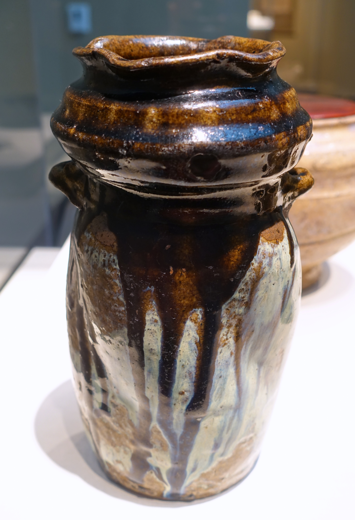

['吉州窑木叶天目盏'] ['陶瓷器物', '文物摄影'] 一只置于白色背景上的黑釉茶盏，盏身布满褐色木叶状斑纹，口沿处有褐色装饰带，底部可见圈足。
[{'location': '画面中央', 'content': '黑釉盏身，表面分布着大小不一的褐色木叶状斑纹，釉面有光泽。', 'space': '占据画面主体，呈倒锥形，口大底小。', 'occlusion': '无遮挡，完整可见。'}, {'location': '盏口边缘', 'content': '一圈褐色的口沿装饰，带有细密的纹理。', 'space': '位于盏体最上端，呈水平环状。', 'occlusion': '无遮挡。'}, {'location': '盏底', 'content': '圈足部分，露胎处呈褐色，可见支烧痕迹。', 'space': '位于盏体最下端，支撑整个器物。', 'occlusion': '无遮挡。'}, {'location': '背景', 'content': '纯白色背景，下方有淡淡的投影。', 'space': '环绕器物，提供干净的负空间。', 'occlusion': '无。'}] ['右下角有轻微水印', '盏内不可见']


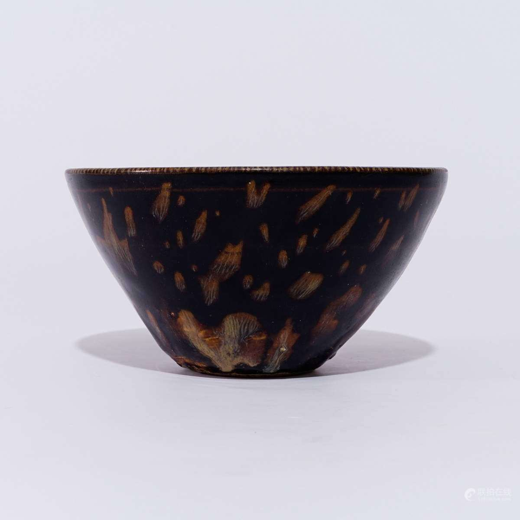

['滨水亲水平台道', '街市招牌'] ['滨水平台', '城市夜景', '公园绿地'] 一幅数字艺术风格的夜景图，前景为紫色调的草地平台，一名女子背对镜头坐着，右侧立有复古路灯，中景为城市灯光与水面，远景为天际线。
[{'location': '画面右下角前景', 'content': '紫色调的草地与植被，一名长发女子背对镜头坐在草地上', 'space': '开阔的草地平台，女子占据部分空间，周围有植被覆盖', 'occlusion': '无遮挡，视野开阔'}, {'location': '画面右侧前景', 'content': '一盏点亮的复古黑色路灯，灯柱细长', 'space': '竖立在草地边缘，占据垂直空间', 'occlusion': '无遮挡'}, {'location': '画面中景', 'content': '城市建筑群与水面，城市灯光闪烁，水面反射天空色彩', 'space': '横向延伸的城市景观，水面占据中景大部分区域', 'occlusion': '无遮挡'}, {'location': '画面上方', 'content': '深蓝色夜空，布满云彩、星星和流星，左上角有一弯新月', 'space': '占据画面上半部分，云层分布不均', 'occlusion': '无遮挡'}] ['图像为数字艺术风格，非真实照片，光影效果较为理想化', '前景植被细节较为模糊，可能影响精细编辑']


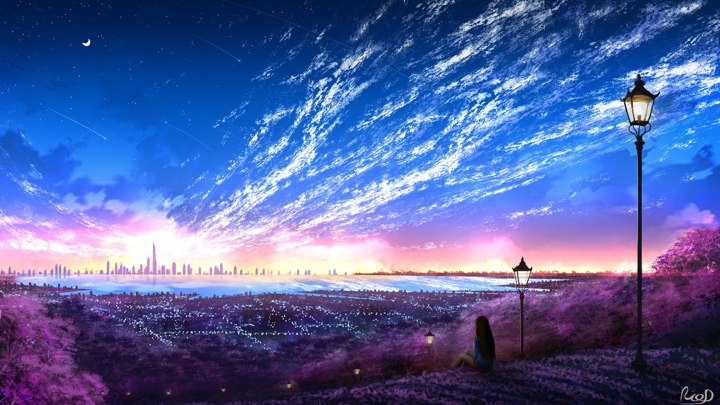

['雅典卫城'] ['历史建筑', '古代遗址', '建筑艺术'] 帕特农神庙局部特写，展示了三根科林斯式石柱、带有浮雕的檐壁以及上方的檐部结构，背景为晴朗蓝天。
[{'location': '画面下方及中部', 'content': '三根带有凹槽的石质圆柱，柱头为科林斯式，表面有风化痕迹。', 'space': '柱体占据主要垂直空间，柱间可见天空背景。', 'occlusion': '无遮挡，柱身完整可见。'}, {'location': '画面上部', 'content': '水平延伸的檐壁（Frieze），表面刻有浮雕图案，包括动物和人物形象。', 'space': '位于柱头上方，横向贯穿画面。', 'occlusion': '无遮挡，浮雕细节清晰。'}, {'location': '画面最上方', 'content': '檐部（Cornice）及顶部的装饰性构件，可见部分兽首装饰。', 'space': '位于檐壁上方，构成建筑顶部轮廓。', 'occlusion': '顶部边缘有轻微裁切。'}] ['视角为仰视，透视变形较大，不适合进行需要水平平面的编辑。', '画面仅展示建筑局部，缺乏地面或完整环境背景。']


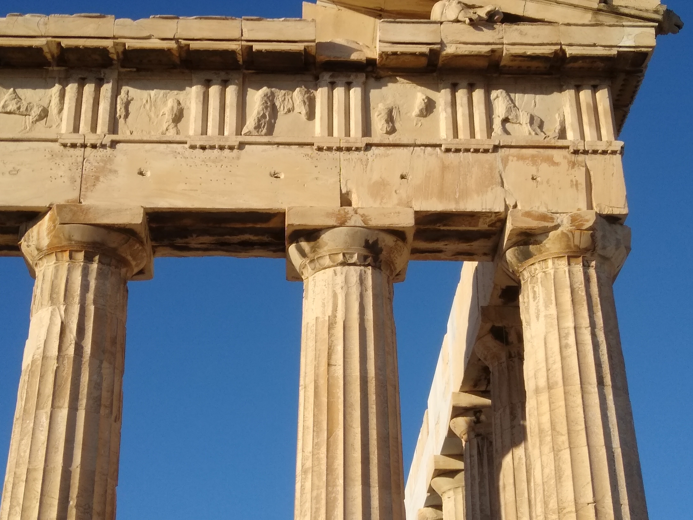

In [5]:
# 原图预览：读 pool 的前 4 行 → 按固定 blob_ref 读取像素 → 缩略展示；不改写结果表。
if 'pool' in result:
    ref = result['pool']
    rows = lance.dataset(ref['uri'], version=ref['version']).to_table(limit=4).to_pylist()
    for row in rows:
        print(row['source_concepts'], row['scene_groups'], row['caption'])
        print(row['regions'], row['issues'])
        raw = BlobRef(**row['blob_ref']).read(root)
        with Image.open(io.BytesIO(raw)) as im:
            im.thumbnail((720, 520))
            display(im.copy())
